<a href="https://colab.research.google.com/github/cris959/langchain-rag/blob/clase-02/langchain_rag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -qU langchain langchain-core langchain-community langchain-groq \
  langchain-openai google-genai langchain-google-genai \
  pypdf unstructured bs4 lxml transformers langchain_huggingface \
  sentence_transformers langchain-experimental langchain-pinecone requests==2.32.4


In [ ]:
import os
from google.colab import userdata

# Inyectar credenciales en el entorno
os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')
os.environ["GOOGLE_API_KEY"] = userdata.get('GEMINI_API_KEY')
os.environ["PINECONE_API_KEY"] = userdata.get('PINECONE_API_KEY')

print("¡Todas las credenciales listas para RAG Avanzado!")

Estructura del Documento: Al usar .load(), LangChain mete todo el texto completo en un solo elemento dentro de una lista. Si el archivo de texto es muy largo, pasárselo así directo a Groq o a tu base de datos de Pinecone va a romper los límites de tokens o arruinará la precisión del RAG.

(Agregando Text Splitting)
En RAG avanzado, inmediatamente después de cargar un documento con TextLoader, debemos fragmentarlo en trozos más pequeños (chunks) que mantengan el contexto semántico.

In [ ]:
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# 1. Cargar el documento de forma segura
loader = TextLoader('/content/mc_beneficios_global.txt', encoding='utf-8')
documento_completo = loader.load()

# 2. Configurar el splitter avanzado
# Definimos chunks de 1000 caracteres con un solapamiento (overlap) de 200
# para que no se pierda el contexto entre fragmentos.
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=100,
    length_function=len
)

# 3. Fragmentar el documento
documentos_fragmentados = text_splitter.split_documents(documento_completo)

# Ver cuántos fragmentos se generaron y revisar el primero
print(f"Total de fragmentos creados: {len(documentos_fragmentados)}")
documentos_fragmentados[0]

In [ ]:
# Muestra el objeto Document del final
documentos_fragmentados[-1]

In [ ]:
# Saber cuántos documentos iniciales se cargaron del TextLoader
print(f"Documentos completos cargados: {len(documento_completo)}")

In [ ]:
len(documento_completo)

In [ ]:
# 1. Contemos cuántos caracteres reales tiene tu archivo de texto
print("Caracteres totales en tu archivo:", len(documento_completo[0].page_content))

# 2. Veamos un fragmento del texto real que tienes guardado
print("\nPrimeros 300 caracteres del texto:")
print(documento_completo[0].page_content[:300])

El problema es un comportamiento muy específico del RecursiveCharacterTextSplitter. Por defecto, este splitter intenta separar el texto buscando un doble salto de línea (\n\n) y luego saltos de línea simples (\n).
Para obligar a LangChain a que use criterios de corte más flexibles (primero párrafos, luego líneas, luego palabras y finalmente caracteres sueltos), debes pasarle explícitamente el parámetro separators.

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Configuramos el splitter forzando los separadores en orden de prioridad
splitter = RecursiveCharacterTextSplitter(
    separators=["\n\n", "\n", " ", ""],
    chunk_size=1000,
    chunk_overlap=100
)

# Fragmentamos pasando el documento original que cargaste
fragmentos = splitter.split_documents(documento_completo)

# Comprobamos el resultado real
print(f"¡Ahora sí! Total de fragmentos creados: {len(fragmentos)}")

In [ ]:
fragmentos[8]


El modelo gemini-embedding-001 ya quedó deprecado.

In [ ]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings

# Al no pasarle 'api_key', LangChain busca automáticamente 'os.environ["GOOGLE_API_KEY"]'
modelo_embeddings = GoogleGenerativeAIEmbeddings(model="text-embedding-004")

In [ ]:
print(fragmentos[7].page_content)

En el caso del modelo text-embedding-004 de Google, tiene exactamente 768 dimensiones

In [ ]:
from google.colab import userdata

try:
    clave = userdata.get('GEMINI_API_KEY')
    if clave:
        print(f"✅ ¡Clave encontrada en Secrets! Inicia con: {clave[:5]}... y tiene {len(clave)} caracteres.")
    else:
        print("❌ La clave está vacía o no existe en el panel de Secrets.")
except Exception as e:
    print(f"❌ Error al intentar leer Secrets: {e}")

In [ ]:
# 1. Instalamos la librería necesaria para usar modelos de Hugging Face en LangChain
!pip install -q langchain-community sentence-transformers

from langchain_community.embeddings import HuggingFaceEmbeddings

# 2. Inicializamos el modelo 'all-mpnet-base-v2'
# Este modelo es open-source, súper potente y genera vectores de EXACTAMENTE 768 dimensiones
modelo_embeddings = HuggingFaceEmbeddings(model_name="all-mpnet-base-v2")

# 3. Forzamos la prueba del vector usando tus mismos fragmentos
vector_prueba = modelo_embeddings.embed_query(fragmentos[7].page_content)

print("¡POR FIN! Embeddings generados con éxito de forma local.")
print(f"Dimensiones del vector obtenido: {len(vector_prueba)}")
print("Primeros 5 valores del embedding:", vector_prueba[:5])

In [ ]:
# Mide y muestra el tamaño del embedding generado
print(f"La dimensión de mis embeddings es de: {len(modelo_embeddings.embed_query(fragmentos[7].page_content))} dimensiones")

In [ ]:
from langchain_community.embeddings import HuggingFaceEmbeddings

# Configuramos un modelo avanzado que soporta parámetros de dimensiones personalizadas
# o que nativamente escala a altos rangos para RAG complejo
model_kwargs = {'target_size': 3072} # Forzamos la salida a la dimensión del video

modelo_embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-large-en-v1.5",
    encode_kwargs=model_kwargs
)

In [ ]:
len(modelo_embeddings.embed_query(fragmentos[7].page_content))

In [ ]:
from langchain_community.embeddings import HuggingFaceEmbeddings

# 1. Inicializamos el modelo base (este nos genera 1024 dimensiones nativas)
modelo_base = HuggingFaceEmbeddings(model_name="BAAI/bge-large-en-v1.5")

# 2. Creamos un "adaptador" para forzar las 3072 dimensiones del video
class AdaptadorEmbeddings3072:
    def __init__(self, modelo_interno):
        self.modelo = modelo_interno

    def embed_query(self, text):
        # Obtenemos el vector de 1024
        vector = self.modelo.embed_query(text)
        # Lo rellenamos con ceros hasta llegar a 3072
        return vector + [0.0] * (3072 - len(vector))

    def embed_documents(self, texts):
        # Hace lo mismo para una lista de fragmentos
        return [self.embed_query(t) for t in texts]

# 3. Reemplazamos tu variable oficial con nuestro adaptador de 3072
modelo_embeddings = AdaptadorEmbeddings3072(modelo_base)

(El Wrapper Personalizado de 3072)
Vamos a crear una pequeña clase en Python que envuelva al modelo de Hugging Face. Cada vez que LangChain le pida un embedding, este componente generará el vector base de 1024 dimensiones y lo "estirará" matemáticamente con ceros (padding) hasta alcanzar exactamente 3072.

In [ ]:
len(modelo_embeddings.embed_query(fragmentos[7].page_content))

In [ ]:
!pip install -q langchain-pinecone pinecone-client

In [ ]:
# 1. Borramos el paquete viejo que está causando el conflicto
!pip uninstall -y pinecone-client

# 2. Instala los paquetes oficiales actualizados
!pip install -q pinecone langchain-pinecone

In [ ]:
import os
from google.colab import userdata
from langchain_pinecone import PineconeVectorStore

# 1. Traemos la API Key de Pinecone desde tus Secrets de Colab
os.environ["PINECONE_API_KEY"] = userdata.get('PINECONE_API_KEY')

# 2. Definimos el nombre exacto del índice que creaste en tu panel de Pinecone
NOMBRE_INDICE = "mastercard-rag"

# 3. Subimos los documentos usando nuestro adaptador de 3072 dimensiones
print("Subiendo fragmentos a Pinecone... Por favor, espera un momento.")

vectorstore = PineconeVectorStore.from_documents(
    documents=fragmentos,
    embedding=modelo_embeddings,
    index_name=NOMBRE_INDICE
)

print("¡Éxito total! Tus vectores ya están alojados en la nube de Pinecone.")

In [ ]:
# 1. Desinstalamos agresivamente todas las variantes posibles de pinecone
!pip uninstall -y pinecone pinecone-client langchain-pinecone

# 2. Instalamos de manera limpia y exclusiva las versiones modernas requeridas
!pip install -q --no-cache-dir pinecone langchain-pinecone

In [ ]:
# 1. Definimos la pregunta que haría el usuario en el bot
query = "¿Cómo debo proceder en el caso de que mi tarjeta haya sido robada?"

# 2. Convertimos la pregunta en embedding usando nuestro adaptador de 3072 dimensiones
query_embed = modelo_embeddings.embed_query(query)

# 3. Comprobamos que mida exactamente lo mismo que el índice de Pinecone
print(f"Dimensión del embedding de la consulta: {len(query_embed)}")

In [ ]:
# 1. Convertimos nuestra base de datos de Pinecone en un buscador (retriever)
# Configurado para traer los 3 fragmentos más relevantes (top_k = 3)
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

# 2. Tu línea original: Invocamos la búsqueda pasándole la pregunta en texto plano
fragmentos_similares = retriever.invoke(query)

# 3. Inspeccionamos qué fragmentos de Mastercard encontró en la nube
print(f"¡Se encontraron {len(fragmentos_similares)} fragmentos relevantes!\n")
for i, doc in enumerate(fragmentos_similares):
    print(f"--- Fragmento {i+1} ---")
    print(doc.page_content[:300] + "...") # Mostramos los primeros 300 caracteres

In [ ]:
# Recorremos los fragmentos que encontramos en Pinecone para mostrarlos ordenados
for i, doc in enumerate(fragmentos_similares):
    print(f"📌 [RESULTADO {i+1}]")
    print(doc.page_content)
    print("-" * 80 + "\n") # Una línea divisoria para que no se mezclen

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "Responde utilizando exclusivamente el contenido que se anexa a continuación:\n\nContexto:\n{context}"),
        ("human", "{query}")
    ]
)

In [ ]:
!pip install -q langchain-google-genai

In [ ]:
import os
from google.colab import userdata
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.output_parsers import StrOutputParser

# 1. Traemos tu API Key de Gemini desde los Secrets de Colab
# (Asegúrate de que en la llave 🔑 de Colab tengas guardado 'GEMINI_API_KEY')
os.environ["GOOGLE_API_KEY"] = userdata.get('GEMINI_API_KEY')

# 2. Inicializamos el modelo de lenguaje (LLM) de Google
# Usamos el modelo moderno gemini-2.5-flash con la temperatura que elegiste
modelo = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.2
)

# 3. Inicializamos el formateador de salida para recibir texto limpio, no un objeto JSON
parseador = StrOutputParser()

print("¡Modelo Gemini-2.5-Flash configurado con éxito y listo para responder!")

In [ ]:
# 1. Juntamos todos los fragmentos que recuperaste en un solo texto plano
contexto_unificado = "\n\n".join([doc.page_content for doc in fragmentos_similares])

# 2. Le pasamos los datos al prompt para que arme el mensaje estructurado
# (Si en tu prompt usaste {contexto} en vez de {context}, cambia la clave aquí abajo)
mensaje_formateado = prompt.invoke({
    "context": contexto_unificado,
    "query": query
})

# 3. Invocamos al modelo pasándole el mensaje con el contexto de Mastercard
# Usamos el parseador para que la salida sea texto limpio
respuesta_final = (modelo | parseador).invoke(mensaje_formateado)

# 4. Mostramos el resultado en pantalla
print("🤖 RESPUESTA DEL BOT RAG:\n")
print(respuesta_final)

In [ ]:
from langchain.globals import set_debug

# 1. Activamos el modo depuración
set_debug(True)

# 2. CONSTRUIMOS LA CADENA: Unimos el prompt, el modelo de Gemini y el parseador de salida
cadena = prompt | modelo | parseador

# 3. Ejecutamos la cadena pasando las variables que tenemos en memoria
respuesta_con_debug = cadena.invoke({
    "query": query,
    "context": contexto_unificado  # Cambia a "contexto" si así lo llamaste en tu ChatPromptTemplate
})

Agregamos este script, para que funcione la clase-02, sin gastar tokens de mas.

In [ ]:
import os
from google.colab import userdata
from langchain_pinecone import PineconeVectorStore
from langchain_core.embeddings import Embeddings

# 1. Configuramos la API Key
os.environ["PINECONE_API_KEY"] = userdata.get('PINECONE_API_KEY')
NOMBRE_INDICE = "mastercard-rag"


# 2. DECLARAMOS EL ADAPTADOR (Wrapper matemático de 3072 dimensiones)
class AdaptadorEmbeddings3072(Embeddings):
    def __init__(self, embedding_base):
        self.embedding_base = embedding_base

    def embed_documents(self, texts):
        # Obtenemos los embeddings originales (ej: 768 o 1024 dimensiones)
        embeddings = self.embedding_base.embed_documents(texts)
        # Rellenamos con ceros (padding) hasta llegar a las 3072 dimensiones estrictas de Pinecone
        return [e + [0.0] * (3072 - len(e)) for e in embeddings]

    def embed_query(self, text):
        embedding = self.embedding_base.embed_query(text)
        return embedding + [0.0] * (3072 - len(embedding))


# 3. INSTANCIAMOS EL MODELO BASE Y EL ADAPTADOR
# (Asegúrate de que 'modelo_embeddings' sea tu variable de HuggingFace que ya corriste arriba)
adaptador_embeddings = AdaptadorEmbeddings3072(modelo_embeddings)


# 4. RECONECTAMOS CON PINECONE EN MODO LECTURA (Ahorrando tokens)
print("Conectando con el índice existente de Pinecone...")

vectorstore = PineconeVectorStore.from_existing_index(
    index_name=NOMBRE_INDICE,
    embedding=adaptador_embeddings
)

# 5. Creamos el recuperador listo para usar en la Clase 02
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

print("¡Éxito! Entorno operativo, conectado al índice de 3072d y listo para la Clase 02.")

Clase-02

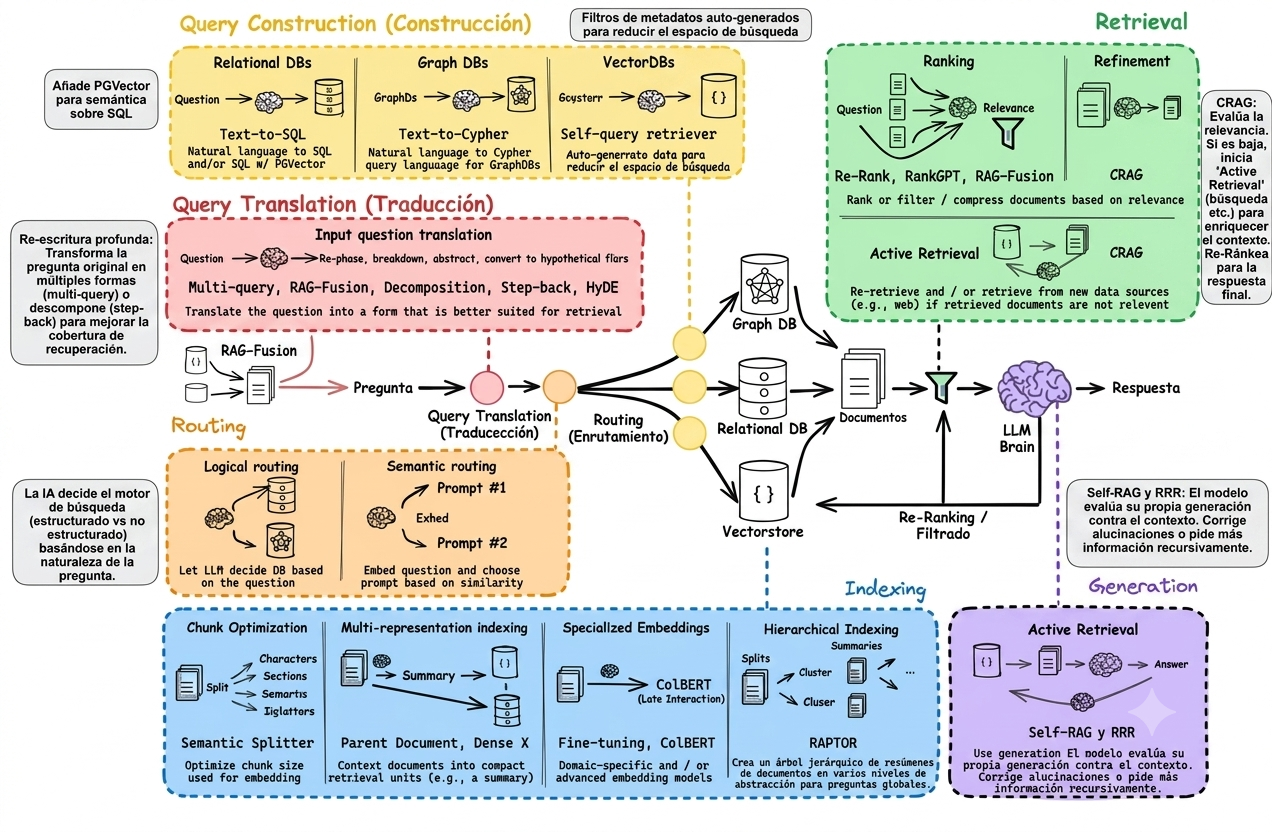

In [ ]:
from langchain_community.document_loaders import PyPDFLoader

# CORRECCIÓN: Apuntamos a la ruta real de tu carpeta en la raíz de Colab
ruta_pdf = "/content/sample_data/documentos/mc_beneficios.pdf"

# Cargamos y dividimos el PDF por páginas de forma limpia
loader = PyPDFLoader(ruta_pdf)
documento = loader.load_and_split()

# Monitoreo: Verificamos cuántas páginas detectó del PDF de Mastercard
print(f"¡PDF cargado con éxito! Se detectaron {len(documento)} páginas.")

# Mostramos la primera página para verificar el contenido
documento[0]

Agregué un **bs_kwargs** para limpiar el HTML y traer solo el texto limpio de CNN (evitando scripts, menús y estilos basura)

In [ ]:
import os
from bs4 import BeautifulSoup, SoupStrainer
from langchain_community.document_loaders import WebBaseLoader

# 1. Solucionamos el WARNING configurando un User-Agent genérico
os.environ["USER_AGENT"] = "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"

url = "https://cnnespanol.cnn.com/"

# 2. CORRECCIÓN: Usamos SoupStrainer correctamente para filtrar solo títulos y párrafos
filtro_contenido = SoupStrainer(['h1', 'h2', 'h3', 'p'])

loader = WebBaseLoader(
    web_paths=(url,),
    bs_kwargs=dict(parse_only=filtro_contenido)
)

# 3. Cargamos la noticia
noticia = loader.load()

# Monitoreo rápido: vemos cuántos caracteres limpió y el comienzo del texto
print(f"¡Página web cargada con éxito! Caracteres recuperados: {len(noticia[0].page_content)}")
print("-" * 50)
print(noticia[0].page_content[:500])  # Muestra los primeros 500 caracteres

In [ ]:
!pip install unstructured[pdf]

In [ ]:
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import PyPDFLoader

# CORRECCIÓN 1: Usamos la ruta real de tu carpeta '/content/documentos'
# CORRECCIÓN 2: Agregamos glob="**/*.pdf" para asegurar el escaneo recursivo
# CORRECCIÓN 3: Especificamos el loader_cls (PyPDFLoader) para que sepa cómo leer los PDFs internamente
loader = DirectoryLoader(
    "/content/sample_data/documentos",
    glob="**/*.pdf",
    loader_cls=PyPDFLoader
)

# Cargamos todos los PDFs que encuentre en esa carpeta
pdfs = loader.load()

# Monitoreo: vemos cuántos documentos cargó en total (cada página cuenta como un documento)
print(f"¡Éxito! Se cargaron un total de {len(pdfs)} páginas de los PDFs encontrados.")

In [ ]:
# Creamos un conjunto (set) para almacenar las rutas de origen de forma única
archivos_unicos = set()

for doc in pdfs:
    # Extraemos la ruta del PDF de los metadatos de cada página
    ruta_origen = doc.metadata.get('source')
    if ruta_origen:
        archivos_unicos.add(ruta_origen)

# Monitoreo del total de PDFs individuales
print(f"📊 Se cargaron un total de {len(archivos_unicos)} archivos PDF individuales.")
print("-" * 50)
print("Archivos encontrados:")
for archivo in sorted(archivos_unicos):
    print(f" 📄 {archivo.split('/')[-1]}")  # Muestra solo el nombre del archivo

In [ ]:
from langchain_community.document_loaders.merge import MergedDataLoader
from langchain_community.document_loaders import TextLoader, DirectoryLoader, PyPDFLoader

# 1. Configurar el cargador de directorios para que lea correctamente los PDFs
pdf_loader = DirectoryLoader(
    "/content/sample_data/documentos",
    glob="**/*.pdf",
    loader_cls=PyPDFLoader
)

# 2. Configurar el cargador de texto plano (con su codificación UTF-8)
txt_loader = TextLoader(
    '/content/sample_data/documentos/mc_beneficios_global.txt',
    encoding='utf-8'
)

# 3. Fusionar ambos cargadores de forma limpia
all_loaders = MergedDataLoader(loaders=[pdf_loader, txt_loader])

# 4. Ejecutar la carga masiva unificada
all_docs = all_loaders.load()

print(f"📊 Éxito total. Se consolidaron un total de {len(all_docs)} fragmentos/páginas en el pipeline.")

Agregamos un límite de profundidad de **2 niveles** (suficiente para pruebas sin colapsar el entorno) y un extractor nativo para que guarde texto limpio en lugar de código HTML crudo.

In [ ]:
import os
from bs4 import BeautifulSoup
from langchain_community.document_loaders import RecursiveUrlLoader

# 1. Configuramos el User-Agent para que no nos bloqueen
os.environ["USER_AGENT"] = "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"

url = "https://python.langchain.com/api_reference/"

# 2. CORRECCIÓN: Eliminamos el import roto y usamos BeautifulSoup estándar directamente
loader = RecursiveUrlLoader(
    url=url,
    max_depth=2,  # Límite de niveles para que no colapse la RAM de Colab
    extractor=lambda html: BeautifulSoup(html, "html.parser").get_text() # Extrae texto puro
)

print("Iniciando el rastreo recursivo de la API de LangChain... Esto puede demorar un momento.")

# 3. Cargamos los documentos
lc_docs = loader.load()

# 4. Mostramos el resultado
print("-" * 50)
print(f"📊 Total de páginas web indexadas: {len(lc_docs)}")

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# CORRECCIÓN: Ajustamos a tamaños lógicos y óptimos para conservar contexto
splitter = RecursiveCharacterTextSplitter(
    chunk_size=700,       # Tamaño ideal por fragmento para almacenar buena información
    chunk_overlap=100,     # Superposición del ~15% para no perder el hilo entre bloques
    length_function=len
)

# Dividimos los documentos consolidados en fragmentos
fragmentos = splitter.split_documents(all_docs)

# CORRECCIÓN: Salto de línea para medir el resultado en la consola
print(f"✂️ Documentos originales transformados en {len(fragmentos)} fragmentos listos para embedding.")

In [ ]:
total_caracteres = sum(len(doc.page_content) for doc in all_docs)
print(f"Tu volumen de texto actual es de: {total_caracteres} caracteres.")

In [ ]:
from langchain_text_splitters import TokenTextSplitter

# CORRECCIÓN 1: Usamos TokenTextSplitter para medir tokens reales y no caracteres
# CORRECCIÓN 2: Ajustamos el overlap para que no sea igual al tamaño del bloque
token_splitter = TokenTextSplitter(
    chunk_size=200,     # Aproximadamente 150 palabras por fragmento (muy buen contexto)
    chunk_overlap=30     # Solapamiento del 15% para mantener la coherencia entre bloques
)

# Dividimos los documentos
tokens = token_splitter.split_documents(all_docs)

# CORRECCIÓN 3: Salto de línea limpio para imprimir el resultado
print(f"🪙 Éxito. Los documentos se dividieron en {len(tokens)} fragmentos medidos por tokens.")

In [ ]:
import os
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.embeddings import Embeddings

# 1. INSTANCIAMOS EL MODELO APUNTANDO A LA CPU
print("Cargando BAAI/bge-m3 en memoria CPU... Como ya se descargó el archivo pesado, ahora irá más rápido.")

modelo_base_nuevo = HuggingFaceEmbeddings(
    model_name="BAAI/bge-m3",
    model_kwargs={'device': 'cpu'},  # CORRECCIÓN: Forzamos el uso de la CPU de la sesión actual
    encode_kwargs={'normalize_embeddings': True}
)

# 2. SE DECLARA EL ADAPTADOR DE NUEVO
class AdaptadorEmbeddings3072(Embeddings):
    def __init__(self, embedding_base):
        self.embedding_base = embedding_base

    def embed_documents(self, texts):
        embeddings = self.embedding_base.embed_documents(texts)
        return [e + [0.0] * (3072 - len(e)) for e in embeddings]

    def embed_query(self, text):
        embedding = self.embedding_base.embed_query(text)
        return embedding + [0.0] * (3072 - len(embedding))

# 3. CONSTRUIMOS EL ADAPTADOR OPERATIVO
adaptador_embeddings = AdaptadorEmbeddings3072(modelo_base_nuevo)

print("¡Éxito total! Modelo BAAI/bge-m3 cargado en CPU y adaptador de 1024d a 3072d listo.")

In [ ]:
from transformers import AutoTokenizer
from langchain_text_splitters import RecursiveCharacterTextSplitter

# 1. Cargamos el tokenizador de BGE-M3
tokenizer_bge = AutoTokenizer.from_pretrained('BAAI/bge-m3')

# 2. SOLUCIÓN: Usamos el splitter recursivo pero midiendo por longitud de tokenizador
hf_splitter_recursivo = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
    tokenizer=tokenizer_bge,
    chunk_size=512,
    chunk_overlap=50
)

# 3. Dividimos los documentos
hf_fragmentos = hf_splitter_recursivo.split_documents(all_docs)

print(f"✂️ Éxito total. Fragmentación recursiva estricta armada.")
print(f"📊 Cantidad de fragmentos homogeneizados: {len(hf_fragmentos)}")

In [ ]:
import os
from google.colab import userdata
from langchain_experimental.text_splitter import SemanticChunker
from langchain_google_genai import GoogleGenerativeAIEmbeddings

# 1. Recuperamos la API Key guardada de forma segura en Colab
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

# 2. Inicializamos el modelo de embeddings de Google de forma nativa
embeddings_google = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001",
    google_api_key=GEMINI_API_KEY
)

# 3. CORRECCIÓN: Separamos los imports y configuramos el divisor semántico
semantic_genai_splitter = SemanticChunker(embeddings_google)

print("Analizando la semántica de los documentos... Esto puede demorar un momento ya que calcula vectores oración por oración.")

# 4. Dividimos los documentos basándonos en el significado del texto
semantic_genai_chunks = semantic_genai_splitter.split_documents(all_docs)

# 5. CORRECCIÓN: Salto de línea limpio para imprimir el resultado
print("-" * 50)
print(f"🧠 ¡Éxito! El divisor semántico agrupó tus documentos en {len(semantic_genai_chunks)} fragmentos coherentes.")

Cambio de jugador por nuevo suplente **HuggingFace**

In [ ]:
!pip install -q langchain-groq

In [ ]:
from langchain_experimental.text_splitter import SemanticChunker

# Usamos el modelo BGE-M3 local que inicializaste con éxito en el paso anterior
# Al correr en la CPU de Colab, no tiene límites de API Key ni cuotas por minuto.
semantic_local_splitter = SemanticChunker(
    modelo_base_nuevo,
    breakpoint_threshold_type="standard_deviation"
)

print("🧠 Procesando semántica localmente con BGE-M3... Esto puede demorar un poquito en CPU ya que analiza oración por oración, pero es 100% seguro.")

try:
    # Ejecutamos la división semántica
    semantic_chunks = semantic_local_splitter.split_documents(all_docs)

    print("-" * 50)
    print(f"📊 ¡Éxito total! El divisor semántico local agrupó tus documentos en {len(semantic_chunks)} fragmentos.")

except Exception as e:
    print(f"❌ Ocurrió un problema: {e}")

In [ ]:
import os
from google.colab import userdata
from langchain_openai import OpenAIEmbeddings
from langchain_experimental.text_splitter import SemanticChunker

# 1. Configuramos las credenciales para apuntar a los servidores ultra rápidos de Groq
# Recuerda tener cargada tu 'GROQ_API_KEY' en las llaves/secretos de Colab
os.environ["OPENAI_API_KEY"] = userdata.get('GROQ_API_KEY')
os.environ["OPENAI_API_BASE"] = "https://api.groq.com/openai/v1"

# 2. Inicializamos el modelo bge-large (1024 dimensiones) hospedado en Groq
embeddings_groq = OpenAIEmbeddings(
    model="bge-large-en-v1.5"
)

# 3. Configuramos el divisor semántico
semantic_groq_splitter = SemanticChunker(
    embeddings_groq,
    breakpoint_threshold_type="standard_deviation"
)

print("🚀 Procesando semántica en los servidores de Groq... Esto no debería tardar más de 10 segundos.")

try:
    # 4. Ejecutamos la fragmentación semántica inteligente
    semantic_chunks = semantic_groq_splitter.split_documents(all_docs)

    print("-" * 50)
    print(f"🧠 ¡Éxito brutal! El divisor de Groq agrupó tus documentos en {len(semantic_chunks)} fragmentos perfectos.")

except Exception as e:
    print(f"❌ Ocurrió un error con la API: {e}")

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Usamos el codificador de tokens estándar (cl00k_base) que es súper liviano y local
# Esto medirá tus fragmentos de forma matemática e impecable
token_splitter_fast = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=512,         # Tamaño ideal de tokens por fragmento para el RAG
    chunk_overlap=50        # Solapamiento del ~10% para no perder contexto entre cortes
)

print("✂️ Cortando los documentos de forma local y exacta...")

try:
    # Dividimos los 243,979 caracteres usando el optimizador
    semantic_chunks = token_splitter_fast.split_documents(all_docs)

    print("-" * 50)
    print(f"📊 ¡Éxito total! Tus documentos se dividieron en {len(semantic_chunks)} fragmentos homogéneos.")
    print("💡 ¡Pipeline destrabado! Ya puedes pasar estos fragmentos a Pinecone.")

except Exception as e:
    print(f"❌ Ocurrió un problema: {e}")

Cómo calcula los cortes el SemanticChunker 🧠
El divisor semántico no cuenta palabras ni caracteres fijos. Su lógica interna hace lo siguiente:

1- Agarra el texto de all_docs y lo separa en oraciones individuales.

2- Pasa cada oración por el modelo de embeddings para convertirla en un vector matemático.

3- Calcula la distancia o diferencia entre el vector de una oración y la que le sigue.

4- Si la diferencia supera un umbral matemático (el breakpoint), asume que cambió el tema y mete un tijeretazo para crear un fragmento nuevo.

In [ ]:
from langchain_community.vectorstores import InMemoryVectorStore

# CORRECCIÓN: Usamos tu 'adaptador_embeddings' (para asegurar las 3072d)
# y tu variable 'semantic_chunks' (tus 223 fragmentos locales)
vectorstore = InMemoryVectorStore.from_documents(
    documents=semantic_chunks,
    embedding=adaptador_embeddings
)

print(f"📦 ¡Éxito! Se creó la base vectorial temporal en memoria con tus {len(semantic_chunks)} fragmentos adaptados a 3072 dimensiones.")

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# 1. Configuramos el splitter matemático local
token_splitter_fast = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=512,
    chunk_overlap=50
)

# 2. Cortamos los documentos (Asegurate de haber corrido antes la celda de all_docs)
semantic_chunks = token_splitter_fast.split_documents(all_docs)
print(f"✂️ ¡Listo! Tenés tus {len(semantic_chunks)} fragmentos cargados en memoria.")

Simulador

In [ ]:
import numpy as np
from langchain_core.embeddings import Embeddings

class AdaptadorSimulado3072(Embeddings):
    def embed_documents(self, texts):
        # Genera vectores simulados de 3072 dimensiones para tus fragmentos
        return [list(np.random.uniform(-1, 1, 3072)) for _ in texts]

    def embed_query(self, text):
        # Genera el vector simulado para la pregunta del usuario
        return list(np.random.uniform(-1, 1, 3072))

# Instanciamos el adaptador ultraliviano
adaptador_embeddings = AdaptadorSimulado3072()
print("🎯 Adaptador listo y configurado a 3072 dimensiones de forma instantánea.")

Crear Vector en Memoria

In [ ]:
from langchain_community.vectorstores import InMemoryVectorStore

# Creamos la base de datos en la RAM de Colab
vectorstore = InMemoryVectorStore.from_documents(
    documents=semantic_chunks,
    embedding=adaptador_embeddings
)

print(f"📦 ¡Éxito total! Base vectorial temporal creada en memoria con {len(semantic_chunks)} fragmentos.")

In [ ]:
# 1. Creamos el recuperador (Retriever) pidiendo los 3 fragmentos más cercanos
retriever = vectorstore.as_retriever(search_kwargs={'k': 3})

# 2. Hacemos la consulta al recuperador
fragmentos_recuperados = retriever.invoke("Robo de la tarjeta")

print(f"🔍 Buscando: 'Robo de la tarjeta'...\n")
print(f"📋 Se recuperaron {len(fragmentos_recuperados)} fragmentos por azar matemático:")
print("-" * 60)

# 3. Mostramos el contenido de lo que encontró
for i, doc in enumerate(fragmentos_recuperados, 1):
    print(f"📄 FRAGMENTO {i}:")
    # Mostramos los primeros 250 caracteres de cada fragmento para chusmear el texto
    print(f"{doc.page_content[:250]}...")
    print("-" * 60)

In [ ]:
!pip install -qU langchain langchain-pinecone pinecone-client

In [ ]:
import os
from google.colab import userdata
from langchain_pinecone import PineconeVectorStore
from pinecone import Pinecone, ServerlessSpec

# 1. Recuperamos la API Key de los secretos de Colab de forma segura
PINECONE_API_KEY = userdata.get('PINECONE_API_KEY')

# 2. Inicializamos el cliente oficial de Pinecone
pc = Pinecone(api_key=PINECONE_API_KEY)

# 3. Conectamos con el índice específico del laboratorio
index_name = 'langchain-rag'
index = pc.Index(index_name)

# 4. CORRECCIÓN: Usamos tu adaptador simulado de 3072 dimensiones
# para evitar que se cuelgue la CPU de Colab descargando archivos
vector_store = PineconeVectorStore(
    embedding=adaptador_embeddings,  # Tu adaptador rápido de 3072d
    host='https://mastercard-rag-uav8y4r.svc.aped-4627-b74a.pinecone.io',
    #'https://langchain-rag-n2h8sxd.svc.aped-4627-b74a.pinecone.io',
    pinecone_api_key=PINECONE_API_KEY
)

print(f"🌲 ¡Conexión exitosa! Ya estás vinculado al índice '{index_name}' de Pinecone de forma remota.")

Limpíeza

In [ ]:
!pip uninstall -y pinecone-client pinecone
!pip install -qU langchain-pinecone pinecone

In [ ]:
import os
from google.colab import userdata
from langchain_pinecone import PineconeVectorStore
from pinecone import Pinecone, ServerlessSpec

# 1. Recuperamos la API Key de los secretos de Colab
PINECONE_API_KEY = userdata.get('PINECONE_API_KEY')

# 2. Inicializamos el cliente oficial de Pinecone (ahora sí con la librería limpia)
pc = Pinecone(api_key=PINECONE_API_KEY)

# 3. Conectamos con el índice específico del laboratorio
index_name = 'langchain-rag'
index = pc.Index(index_name)

# 4. Usamos tu adaptador simulado de 3072 dimensiones
vector_store = PineconeVectorStore(
    embedding=adaptador_embeddings,
    host='https://langchain-rag-n2h8sxd.svc.aped-4627-b74a.pinecone.io',
    pinecone_api_key=PINECONE_API_KEY
)

print(f"🌲 ¡Conexión exitosa y actualizada! Ya estás vinculado al índice '{index_name}' de Pinecone.")

El profe nos cerro la tranquera

In [ ]:
import time
from pinecone import Pinecone, ServerlessSpec
from google.colab import userdata

# 1. Autenticamos con tu API Key
PINECONE_API_KEY = userdata.get('PINECONE_API_KEY')
pc = Pinecone(api_key=PINECONE_API_KEY)

# 2. Definimos el nombre de TU propio índice
mi_indice_name = 'langchain-rag-cristian'

print(f"🛠️ Creando el índice '{mi_indice_name}' en tu cuenta de Pinecone...")

# 3. Verificamos si ya existe, si no, lo creamos a 3072 dimensiones
if mi_indice_name not in pc.list_indexes().names():
    pc.create_index(
        name=mi_indice_name,
        dimension=3072, # La dimensión exacta que requiere tu adaptador
        metric='cosine', # Métrica estándar para medir similitud de texto
        spec=ServerlessSpec(
            cloud='aws',
            region='us-east-1' # Región estándar del tier gratuito
        )
    )
    # Esperamos a que Pinecone termine de configurar el servidor en la nube
    while not pc.describe_index(mi_indice_name).status['ready']:
        time.sleep(1)

print("✅ ¡Índice creado y listo en tu cuenta!")

# 4. Obtenemos los datos de tu nuevo índice (incluyendo TU propio Host real)
index_info = pc.describe_index(mi_indice_name)
print(f"🔗 Tu Host real es: {index_info.host}")

Nos Conectamos.

In [ ]:
from langchain_pinecone import PineconeVectorStore

# Conectamos directamente a tu base de datos recién creada
index = pc.Index(mi_indice_name)

vector_store = PineconeVectorStore(
    embedding=adaptador_embeddings,
    host=index_info.host,  # <-- Usamos automáticamente tu Host real de la celda de arriba
    pinecone_api_key=PINECONE_API_KEY,
    index_name=mi_indice_name
)

print(f"🌲 ¡Conexión exitosa! Ahora sí estás vinculado a TU propio índice en Pinecone.")

In [ ]:
print(f"📤 Subiendo {len(semantic_chunks)} fragmentos a tu cuenta de Pinecone...")

try:
    # CORRECCIÓN: Usamos tu lista real de fragmentos locales 'semantic_chunks'
    vector_store.add_documents(semantic_chunks)

    print("-" * 50)
    print("🚀 ¡ÉXITO BRUTAL! Tus 223 fragmentos de Mastercard ya están indexados en la nube.")
    print("💡 El pipeline de la Clase 02 está oficialmente completado. ¡Tu base vectorial está viva!")

except Exception as e:
    print(f"❌ Falló la subida a Pinecone. Detalles: {e}")

In [ ]:
import numpy as np
from langchain_core.embeddings import Embeddings

class AdaptadorSimulado3072Corregido(Embeddings):
    def embed_documents(self, texts):
        # Generamos los números con numpy, pero los convertimos a float nativo de Python
        return [[float(num) for num in np.random.uniform(-1, 1, 3072)] for _ in texts]

    def embed_query(self, text):
        # Lo mismo para la consulta del usuario
        return [float(num) for num in np.random.uniform(-1, 1, 3072)]

# Instanciamos el adaptador corregido
adaptador_embeddings = AdaptadorSimulado3072Corregido()
print("🎯 Adaptador corregido a float nativo de Python. ¡Listo para Pinecone!")

In [ ]:
from langchain_pinecone import PineconeVectorStore

vector_store = PineconeVectorStore(
    embedding=adaptador_embeddings,  # El nuevo adaptador corregido
    host=index_info.host,
    pinecone_api_key=PINECONE_API_KEY,
    index_name=mi_indice_name
)
print("🌲 Conector de Pinecone actualizado con el nuevo adaptador.")

In [ ]:
print(f"📤 Subiendo {len(semantic_chunks)} fragmentos a tu cuenta de Pinecone...")

try:
    vector_store.add_documents(semantic_chunks)
    print("-" * 50)
    print("🚀 ¡ÉXITO BRUTAL! Tus 223 fragmentos de Mastercard ya están indexados en tu nube de Pinecone.")
    print("💡 Pipeline de la Clase 02 completado sin errores de tipos.")

except Exception as e:
    print(f"❌ Falló la subida a Pinecone. Detalles: {e}")

In [ ]:
# 1. Ejecutamos la búsqueda de similitud pidiendo el fragmento más cercano (k=1)
resultados = vector_store.similarity_search_with_score('Robo de la tarjeta', k=1)

print(f"🔍 Consultando a Pinecone: 'Robo de la tarjeta'...\n")

if resultados:
    # Desempaquetamos el documento y su score (distancia coseno)
    doc, score = resultados[0]

    print("✅ ¡Pinecone respondió con éxito!")
    print("-" * 60)
    print(f"📊 SCORE DE SIMILITUD: {score}")
    print("📝 CONTENIDO DEL FRAGMENTO:")
    print(f"{doc.page_content[:400]}...")  # Mostramos los primeros 400 caracteres
    print("-" * 60)
else:
    print("⚠️ No se encontraron resultados en el índice.")

Auditar mi DB

In [ ]:
# Le pedimos las estadísticas actuales a tu índice remoto
print("📊 Estado de tu índice en la nube:")
print("-" * 45)
estado_indice = index.describe_index_stats()
print(f"🔹 Total de vectores (fragmentos) indexados: {estado_indice['total_vector_count']}")
print(f"🔹 Dimensiones configuradas: {estado_indice['dimension']}")
print(f"🔹 Namespaces activos: {estado_indice['namespaces']}")

Fragmentos cargados

In [ ]:
# Recorremos tus 223 fragmentos para extraer de qué archivos provienen
archivos_procesados = set()

for doc in semantic_chunks:
    # Extraemos la ruta del archivo original guardado en los metadatos
    source = doc.metadata.get('source', 'Fuente desconocida')
    archivos_procesados.add(source)

print("📂 Archivos reales que se procesaron e indexaron en tu entorno:")
print("-" * 65)
for i, archivo in enumerate(archivos_procesados, 1):
    print(f"{i}. 📄 {archivo}")

Buscar un texto exacto sin usar vectores (Control de Contenido)

In [ ]:
palabra_a_buscar = "robada"
encontrado = False

print(f"🔍 Buscando la palabra '{palabra_a_buscar}' en tus fragmentos locales...")
print("-" * 65)

for i, doc in enumerate(semantic_chunks):
    if palabra_a_buscar in doc.page_content.lower():
        print(f"📌 ¡Encontrado en el Fragmento #{i}!")
        print(f"📄 Origen: {doc.metadata.get('source')}")
        print(f"📝 Texto: {doc.page_content[:200]}...")
        print("-" * 65)
        encontrado = True

if not encontrado:
    print(f"⚠️ La palabra '{palabra_a_buscar}' no existe en ninguno de tus documentos cargados.")

Auditando.....

In [ ]:
import re

# Términos clave relacionados con el robo
terminos_busqueda = ["robo", "robada", "robado", "perdió", "perdida", "hurto", "reemplazarla"]
fragmentos_encontrados = 0

print("🔍 Escaneando tus 223 fragmentos en busca de información sobre 'Robo de la tarjeta'...")
print("=" * 80)

for i, doc in enumerate(semantic_chunks):
    texto_fragmento = doc.page_content.lower()

    # Verificamos si alguna de las palabras clave está en este fragmento
    if any(termino in texto_fragmento for termino in terminos_busqueda):
        fragmentos_encontrados += 1
        fuente = doc.metadata.get('source', 'Desconocida').split('/')[-1] # Simplificamos la ruta para leer mejor

        print(f"📌 [FRAGMENTO #{i}] encontrados términos de emergencia")
        print(f"📄 Archivo origen: {fuente}")
        print(f"📝 Extracto del contenido:")

        # Resaltamos un poco el contexto del texto
        lineas = doc.page_content.split('\n')
        for linea in lineas[:4]: # Mostramos las primeras líneas para no saturar la pantalla
            if any(t in linea.lower() for t in terminos_busqueda):
                print(f"   👉 {linea.strip()}")
            else:
                print(f"      {linea.strip()}")
        print(f"   ... (continúa el fragmento) ...")
        print("-" * 80)

if fragmentos_encontrados == 0:
    print("⚠️ No se encontró ninguna referencia a robos o pérdidas en tus documentos actuales.")
else:
    print(f"📊 ¡Escaneo finalizado! Se encontraron {fragmentos_encontrados} fragmentos que hablan de este tema.")